In [3]:
import pandas as pd
df=pd.read_csv("C:/Users/abd/OneDrive/Desktop/dataset/titanic.csv")

In [4]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.8 MB/s eta 0:00:27
    --------------------------------------- 1.0/48.9 MB 2.5 MB/s eta 0:00:20
   - -------------------------------------- 2.1/48.9 MB 3.5 MB/s eta 0:00:14
   -- ------------------------------------- 2.6/48.9 MB 3.7 MB/s eta 0:00:13
   -- ------------------------------------- 2.9/48.9 MB 2.8 MB/s eta 0:00:17
   -- ------------------------------------- 2.9/48.9 MB 2.8 MB/s eta 0:00:17
   -- ------------------------------------- 3.4/48.9 MB 2.5 MB/s eta 0:00:19
   -- ------------------------------------- 3.4/48.9 MB 2.5 MB/s eta 0:00:19
   --- ------------------------------------ 4.5/48.9 MB 2.3 MB/s eta 0:00:20
   ---- ----------------------------------- 6.0/48.9 MB 2.8 MB/s eta 0:00:16
   ----- -----------

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

In [6]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df[
    ["SibSp", "Parch", "FamilySize", "IsAlone"]
].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [7]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = df[features].copy()
y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (712, 9)
Testing Shape: (179, 9)


In [9]:
numerical_columns = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

categorical_columns = [
    "Pclass",
    "Sex",
    "Embarked"
]

In [10]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [11]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 81.56 %


In [13]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 81.56 %


In [14]:
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_predictions = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy * 100, 2),
    "%"
)

XGBoost Accuracy: 81.01 %


In [15]:
print("LOGISTIC REGRESSION")
print(classification_report(
    y_test,
    logistic_predictions
))

print("\nRANDOM FOREST")
print(classification_report(
    y_test,
    rf_predictions
))

print("\nXGBOOST")
print(classification_report(
    y_test,
    xgb_predictions
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


XGBOOST
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       110
           1       0.86      0.61      0.71        69

    accuracy                           0.81       179
   macro avg       0.82      0.77      0.79       179
weighted avg       0.82      0

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Metric": [
        "Accuracy",
        "Accuracy",
        "Accuracy"
    ],

    "Score": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison["Score"] = (
    comparison["Score"] * 100
).round(2)

comparison

,Model,Metric,Score
0,Logistic Regression,Accuracy,81.56
1,Random Forest,Accuracy,81.56
2,XGBoost,Accuracy,81.01


In [17]:
rf_feature_names = (
    rf_pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

rf_importance = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importance
})

rf_importance_df = rf_importance_df.sort_values(
    by="Importance",
    ascending=False
)

rf_importance_df.head(10)

,Feature,Importance
3,num__Fare,0.243697
0,num__Age,0.240682
9,cat__Sex_female,0.148616
10,cat__Sex_male,0.134472
8,cat__Pclass_3,0.047644
4,num__FamilySize,0.045056
6,cat__Pclass_1,0.029593
1,num__SibSp,0.027673
2,num__Parch,0.022705
13,cat__Embarked_S,0.015169


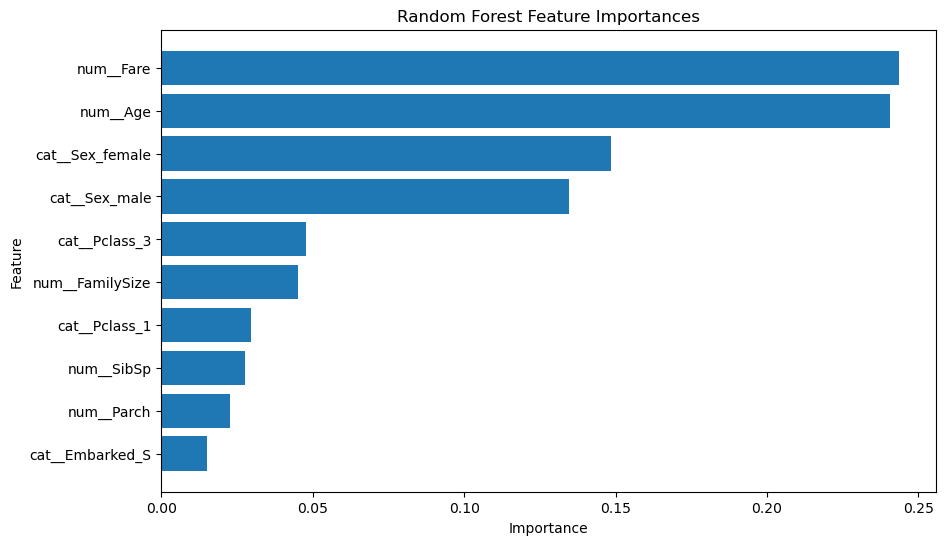

In [18]:
top_rf = rf_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [19]:
xgb_feature_names = (
    xgb_pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

xgb_importance = (
    xgb_pipeline
    .named_steps["model"]
    .feature_importances_
)

xgb_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_importance
})

xgb_importance_df = xgb_importance_df.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance_df.head(10)

,Feature,Importance
9,cat__Sex_female,0.502936
8,cat__Pclass_3,0.139959
6,cat__Pclass_1,0.128341
0,num__Age,0.037909
1,num__SibSp,0.030175
7,cat__Pclass_2,0.029905
13,cat__Embarked_S,0.027376
3,num__Fare,0.026632
11,cat__Embarked_C,0.023852
4,num__FamilySize,0.023060


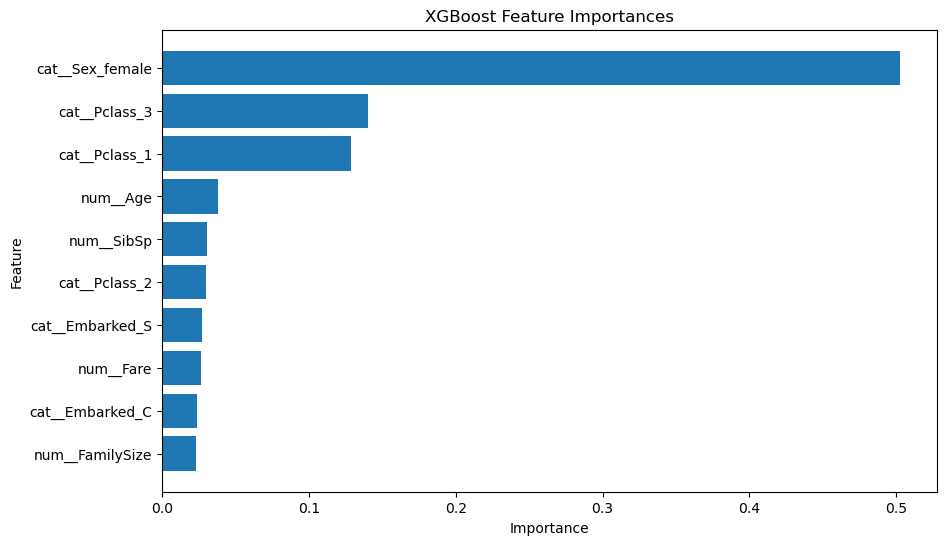

In [20]:
top_xgb = xgb_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xgb["Feature"],
    top_xgb["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [21]:
print("Top 5 Random Forest Features:")
display(rf_importance_df.head(5))

print("Top 5 XGBoost Features:")
display(xgb_importance_df.head(5))

Top 5 Random Forest Features:


,Feature,Importance
3,num__Fare,0.243697
0,num__Age,0.240682
9,cat__Sex_female,0.148616
10,cat__Sex_male,0.134472
8,cat__Pclass_3,0.047644


Top 5 XGBoost Features:


,Feature,Importance
9,cat__Sex_female,0.502936
8,cat__Pclass_3,0.139959
6,cat__Pclass_1,0.128341
0,num__Age,0.037909
1,num__SibSp,0.030175


## Random Forest vs XGBoost

Random Forest builds many decision trees independently using different samples of the training data and then combines their predictions through voting. XGBoost builds trees sequentially, where each new tree tries to correct errors made by the previous trees. Because of this, Random Forest mainly reduces variance by averaging many models, while XGBoost gradually improves the model by focusing on previous mistakes. Both are powerful ensemble methods, but they combine their trees in different ways.

## Model Comparison

Three classification models were tested on the Titanic dataset: Logistic Regression, Random Forest, and XGBoost. Logistic Regression achieved approximately 81.56% accuracy, while Random Forest achieved approximately 81.56% and XGBoost achieved around 81.01%. In this experiment, the ensemble models did not significantly outperform Logistic Regression, showing that a more complex model is not always guaranteed to perform better.

The feature importance analysis also showed some differences between the ensemble models. Random Forest gave high importance to features such as Fare, Age, and Sex, while XGBoost placed particularly strong importance on Sex and passenger class.